In [1]:
## installo HGQ2 , inizialmente dava problemi perchè andava in conflitto con le versioni più recenti di Tensorflow. Cosi sembra funzionare.

!pip install HGQ2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.4/111.4 kB 1.9 MB/s eta 0:00:00


In [2]:
## connessione al google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
import importlib
importlib.invalidate_caches()
# JAX runs the fastest for hgq in general based on our experience
# If you don't have jax, or if you want to use another backend, you can change this to 'tensorflow' or 'torch'
os.environ['KERAS_BACKEND'] = 'jax'
# tested for tensorflow, jax, and torch.
# For the best performance, we recommend using jax, or tensorflow with XLA (jit compile) enabled.
# Jit compilation for torch (torch dynamo) is not supported yet (may or may not work)

import keras
import numpy as np
from matplotlib import pyplot as plt

from hgq.layers import QConv2D, QDense, QMaxPool2D
from hgq.config import LayerConfigScope, QuantizerConfigScope
from hgq.config import QuantizerConfig, QuantizerConfigScope
from hgq.layers import QDense, QSoftmax
from hgq.utils.sugar import FreeEBOPs, PBar, BetaScheduler, ParetoFront

from keras.layers import *
from keras.models import Sequential, Model
from keras.optimizers import Adam, RMSprop

import pickle as pkl
from pathlib import Path

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [4]:
FREQ = 150

In [5]:
help(QDense)

Help on class QDense in module hgq.layers.core.dense:

class QDense(hgq.layers.core.base.QLayerBaseSingleInput, keras.src.layers.core.dense.Dense)
 |  QDense(*args, **kwargs)
 |
 |  Method resolution order:
 |      QDense
 |      hgq.layers.core.base.QLayerBaseSingleInput
 |      hgq.layers.core.base.QLayerBase
 |      keras.src.layers.core.dense.Dense
 |      keras.src.layers.layer.Layer
 |      keras.src.backend.jax.layer.JaxLayer
 |      keras.src.ops.operation.Operation
 |      keras.src.saving.keras_saveable.KerasSaveable
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, units, activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, kq_conf: None | hgq.quantizer.config.QuantizerConfig = None, iq_conf: None | hgq.quantizer.config.QuantizerConfig = None, bq_conf: None | hgq.quantizer.config.QuantizerC

In [6]:
help(input)

Help on method raw_input in module ipykernel.kernelbase:

raw_input(prompt='') method of google.colab._kernel.Kernel instance
    Forward raw_input to frontends

    Raises
    ------
    StdinNotImplementedError if active frontend doesn't support stdin.



In [ ]:
def Keras_MLP_damI(string):

    inTnsr  = Input(shape=(42,), name="input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

    #x = Dense(64, name =string+'fc3')(inTnsr)
    #x = Activation("relu", name=string+'act3') (x)

    x = QDense(32, name ='fc4_'+string, activation='relu')(inTnsr)
    #x = Activation("relu", name='act4_'+string) (x)

    x = QDense(16, name ='fc5_'+string, activation='relu')(x)
    #x = Activation("relu", name='act5_'+string) (x)

    outTnsr = QDense(8, name ='fc6_'+string, activation='relu')(x)
    #outTnsr = Activation("relu", name='act6_'+string) (x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model

def Keras_MLP_damI_time(string):

    inTnsr  = Input(shape=(42*4,), name="input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

    #x = Dense(64, name =string+'fc3')(inTnsr)
    #x = Activation("relu", name=string+'act3') (x)

    x = QDense(32*4, name ='fc4_'+string, activation='relu')(inTnsr)

    x = QDense(64, name ='fc5_'+string, activation='relu')(x)

    x = QDense(32, name ='fc6_'+string, activation='relu')(x)

    x = QDense(16, name ='fc7_'+string, activation='relu')(x)

    outTnsr = QDense(8, name ='fc8_'+string, activation='relu')(x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model

def Keras_MLP_sector(string):

    inTnsr  = Input(shape=(40,), name="sector_input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

   # x = Dense(64, name =string+'fc3')(inTnsr)
   # x = Activation("relu", name=string+'act3') (x)
    x = QDense(20, name ='sector_fc4_'+string)(inTnsr)
    x = Activation("relu", name='sector_act4_'+string) (x)
    x = QDense(16, name ='sector_fc5_'+string)(x)
    x = Activation("relu", name='sector_act5_'+string) (x)
    x = QDense(4, name ='sector_fc6_'+string)(x)
    x = Activation("relu", name='sector_act6_'+string) (x)
    x = QDense(1, name ='sector_fc7_'+string)(x)
    outTnsr = Activation("sigmoid", name='sector_act7_'+string) (x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model


def Keras_CNN_damI(string):
    inTnsr = Input(shape=(42,4,1,),name=string+"input")
    x = QConv2D(filters = 16, kernel_size = 4, padding = 'same', name=string+'conv1', activation='relu')(inTnsr)
    #x = Activation("relu", name=string+'act4') (x)
    x = QMaxPool2D (pool_size = 2, strides = 2, padding ='same', name = string+'maxp1') (x)
    x = QConv2D(filters   = 16, kernel_size = 4, padding ='same', name = string+'conv2',activation='relu') (x)
    #x = Activation("relu", name = string+'act5' ) (x)
    x = QMaxPool2D (pool_size = 2, strides = 2, padding ='same', name = string+'maxp2') (x)
    x = Flatten(name = string+'flatten')(x)
    x = QDense(16, name = string+'fc4',activation='relu') (x)
    #x = Activation("relu", name = string+'act6' ) (x)
    outTnsr = QDense(8, name = string+'fc5', activation='relu') (x)

    model  = Model(inputs=inTnsr, outputs=outTnsr)
    return model

In [ ]:
def Keras_MLP_DAMandTP(Keras_MLP_damI,Keras_MLP_sector):

    x0 = Keras_MLP_damI[0].output
    x1 = Keras_MLP_damI[1].output
    x2 = Keras_MLP_damI[2].output
    x3 = Keras_MLP_damI[3].output
    x4 = Keras_MLP_damI[4].output
    x5 = Keras_MLP_damI[5].output
    x6 = Keras_MLP_damI[6].output
    x7 = Keras_MLP_damI[7].output
    x8 = Keras_MLP_damI[8].output
    x9 = Keras_MLP_damI[9].output
    x10 = Keras_MLP_damI[10].output
    x11 = Keras_MLP_damI[11].output
    x12 = Keras_MLP_damI[12].output
    x13 = Keras_MLP_damI[13].output
    x14 = Keras_MLP_damI[14].output
    x15 = Keras_MLP_damI[15].output
    x16 = Keras_MLP_damI[16].output
    x17 = Keras_MLP_damI[17].output
    x18 = Keras_MLP_damI[18].output
    x19 = Keras_MLP_damI[19].output
    x20 = Keras_MLP_damI[20].output
    x21 = Keras_MLP_damI[21].output
    x22 = Keras_MLP_damI[22].output
    x23 = Keras_MLP_damI[23].output
    x24 = Keras_MLP_damI[24].output
    x25 = Keras_MLP_damI[25].output
    x26 = Keras_MLP_damI[26].output
    x27 = Keras_MLP_damI[27].output
    x28 = Keras_MLP_damI[28].output
    x29 = Keras_MLP_damI[29].output

    x_sec0 = Concatenate(name ='concatenate_0')([x0,x1,x2,x3,x4])
    x_sec1 = Concatenate(name ='concatenate_1')([x5,x6,x7,x8,x9])
    x_sec2 = Concatenate(name ='concatenate_2')([x10,x11,x12,x13,x14])
    x_sec3 = Concatenate(name ='concatenate_3')([x15,x16,x17,x18,x19])
    x_sec4 = Concatenate(name ='concatenate_4')([x20,x21,x22,x23,x24])
    x_sec5 = Concatenate(name ='concatenate_5')([x25,x26,x27,x28,x29])

    string='0'
    x_sec0 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act4_'+string) (x_sec0)
    x_sec0 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act5_'+string) (x_sec0)
    y_sec0 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec0)
    #y_sec0 = Activation("relu", name='sector_act6_'+string) (x_sec0)
    #x_sec0 = Dense(1, name ='sector_fc7_'+string)(x_sec0)
    #y_sec0 = Activation("sigmoid", name='sector_act7_'+string) (x_sec0)

    string='1'
    x_sec1 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act4_'+string) (x_sec1)
    x_sec1 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act5_'+string) (x_sec1)
    y_sec1 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec1)
    #y_sec1 = Activation("relu", name='sector_act6_'+string) (x_sec1)
    #x_sec1 = Dense(1, name ='sector_fc7_'+string)(x_sec1)
    #y_sec1 = Activation("sigmoid", name='sector_act7_'+string) (x_sec1)

    string='2'
    x_sec2 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act4_'+string) (x_sec2)
    x_sec2 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act5_'+string) (x_sec2)
    y_sec2 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec2)
    #y_sec2 = Activation("relu", name='sector_act6_'+string) (x_sec2)
    #x_sec2 = Dense(1, name ='sector_fc7_'+string)(x_sec2)
    #y_sec2 = Activation("sigmoid", name='sector_act7_'+string) (x_sec2)

    string='3'
    x_sec3 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act4_'+string) (x_sec3)
    x_sec3 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act5_'+string) (x_sec3)
    y_sec3 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec3)
    #y_sec3 = Activation("relu", name='sector_act6_'+string) (x_sec3)
    #x_sec3 = Dense(1, name ='sector_fc7_'+string)(x_sec3)
    #y_sec3 = Activation("sigmoid", name='sector_act7_'+string) (x_sec3)

    string='4'
    x_sec4 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act4_'+string) (x_sec4)
    x_sec4 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act5_'+string) (x_sec4)
    y_sec4 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec4)
    #y_sec4 = Activation("relu", name='sector_act6_'+string) (x_sec4)
    #x_sec4 = Dense(1, name ='sector_fc7_'+string)(x_sec4)
    #y_sec4 = Activation("sigmoid", name='sector_act7_'+string) (x_sec4)

    string='5'
    x_sec5 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act4_'+string) (x_sec5)
    x_sec5 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act5_'+string) (x_sec5)
    y_sec5 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec5)
    #y_sec5 = Activation("relu", name='sector_act6_'+string) (x_sec5)
    #x_sec5 = Dense(1, name ='sector_fc7_'+string)(x_sec5)
    #y_sec5 = Activation("sigmoid", name='sector_act7_'+string) (x_sec5)
    y = Concatenate(name ='concatenate_6')([y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])

    outTnsr = QDense(1, name ='fc8_'+"damII", activation='sigmoid')(y)
    #outTnsr    = Activation("sigmoid", name='act8_'+"final") (y)

    model  = Model(inputs=[Keras_MLP_damI[0].input,Keras_MLP_damI[1].input,Keras_MLP_damI[2].input,Keras_MLP_damI[3].input,
                           Keras_MLP_damI[4].input,Keras_MLP_damI[5].input,Keras_MLP_damI[6].input,Keras_MLP_damI[7].input,
                           Keras_MLP_damI[8].input,Keras_MLP_damI[9].input,
                           Keras_MLP_damI[10].input,Keras_MLP_damI[11].input,Keras_MLP_damI[12].input,Keras_MLP_damI[13].input,
                           Keras_MLP_damI[14].input,Keras_MLP_damI[15].input,Keras_MLP_damI[16].input,Keras_MLP_damI[17].input,
                           Keras_MLP_damI[18].input,Keras_MLP_damI[19].input,
                           Keras_MLP_damI[20].input,Keras_MLP_damI[21].input,Keras_MLP_damI[22].input,Keras_MLP_damI[23].input,
                           Keras_MLP_damI[24].input,Keras_MLP_damI[25].input,Keras_MLP_damI[26].input,Keras_MLP_damI[27].input,
                           Keras_MLP_damI[28].input,Keras_MLP_damI[29].input], outputs=
                   #[y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])
                   outTnsr)

    return model


def Keras_CNN_DAMandTP(Keras_CNN_damI,Keras_MLP_sector):

    x0 = Keras_CNN_damI[0].output
    x1 = Keras_CNN_damI[1].output
    x2 = Keras_CNN_damI[2].output
    x3 = Keras_CNN_damI[3].output
    x4 = Keras_CNN_damI[4].output
    x5 = Keras_CNN_damI[5].output
    x6 = Keras_CNN_damI[6].output
    x7 = Keras_CNN_damI[7].output
    x8 = Keras_CNN_damI[8].output
    x9 = Keras_CNN_damI[9].output
    x10 = Keras_CNN_damI[10].output
    x11 = Keras_CNN_damI[11].output
    x12 = Keras_CNN_damI[12].output
    x13 = Keras_CNN_damI[13].output
    x14 = Keras_CNN_damI[14].output
    x15 = Keras_CNN_damI[15].output
    x16 = Keras_CNN_damI[16].output
    x17 = Keras_CNN_damI[17].output
    x18 = Keras_CNN_damI[18].output
    x19 = Keras_CNN_damI[19].output
    x20 = Keras_CNN_damI[20].output
    x21 = Keras_CNN_damI[21].output
    x22 = Keras_CNN_damI[22].output
    x23 = Keras_CNN_damI[23].output
    x24 = Keras_CNN_damI[24].output
    x25 = Keras_CNN_damI[25].output
    x26 = Keras_CNN_damI[26].output
    x27 = Keras_CNN_damI[27].output
    x28 = Keras_CNN_damI[28].output
    x29 = Keras_CNN_damI[29].output

    x_sec0 = Concatenate(name ='concatenate_0')([x0,x1,x2,x3,x4])
    x_sec1 = Concatenate(name ='concatenate_1')([x5,x6,x7,x8,x9])
    x_sec2 = Concatenate(name ='concatenate_2')([x10,x11,x12,x13,x14])
    x_sec3 = Concatenate(name ='concatenate_3')([x15,x16,x17,x18,x19])
    x_sec4 = Concatenate(name ='concatenate_4')([x20,x21,x22,x23,x24])
    x_sec5 = Concatenate(name ='concatenate_5')([x25,x26,x27,x28,x29])

    string='0'
    x_sec0 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act4_'+string) (x_sec0)
    x_sec0 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act5_'+string) (x_sec0)
    y_sec0 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec0)
    #y_sec0 = Activation("relu", name='sector_act6_'+string) (x_sec0)
    #x_sec0 = Dense(1, name ='sector_fc7_'+string)(x_sec0)
    #y_sec0 = Activation("sigmoid", name='sector_act7_'+string) (x_sec0)

    string='1'
    x_sec1 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act4_'+string) (x_sec1)
    x_sec1 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act5_'+string) (x_sec1)
    y_sec1 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec1)
    #y_sec1 = Activation("relu", name='sector_act6_'+string) (x_sec1)
    #x_sec1 = Dense(1, name ='sector_fc7_'+string)(x_sec1)
    #y_sec1 = Activation("sigmoid", name='sector_act7_'+string) (x_sec1)

    string='2'
    x_sec2 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act4_'+string) (x_sec2)
    x_sec2 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act5_'+string) (x_sec2)
    y_sec2 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec2)
    #y_sec2 = Activation("relu", name='sector_act6_'+string) (x_sec2)
    #x_sec2 = Dense(1, name ='sector_fc7_'+string)(x_sec2)
    #y_sec2 = Activation("sigmoid", name='sector_act7_'+string) (x_sec2)

    string='3'
    x_sec3 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act4_'+string) (x_sec3)
    x_sec3 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act5_'+string) (x_sec3)
    y_sec3 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec3)
    #y_sec3 = Activation("relu", name='sector_act6_'+string) (x_sec3)
    #x_sec3 = Dense(1, name ='sector_fc7_'+string)(x_sec3)
    #y_sec3 = Activation("sigmoid", name='sector_act7_'+string) (x_sec3)

    string='4'
    x_sec4 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act4_'+string) (x_sec4)
    x_sec4 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act5_'+string) (x_sec4)
    y_sec4 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec4)
    #y_sec4 = Activation("relu", name='sector_act6_'+string) (x_sec4)
    #x_sec4 = Dense(1, name ='sector_fc7_'+string)(x_sec4)
    #y_sec4 = Activation("sigmoid", name='sector_act7_'+string) (x_sec4)

    string='5'
    x_sec5 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act4_'+string) (x_sec5)
    x_sec5 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act5_'+string) (x_sec5)
    y_sec5 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec5)
    #y_sec5 = Activation("relu", name='sector_act6_'+string) (x_sec5)
    #x_sec5 = Dense(1, name ='sector_fc7_'+string)(x_sec5)
    #y_sec5 = Activation("sigmoid", name='sector_act7_'+string) (x_sec5)
    y = Concatenate(name ='concatenate_6')([y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])

    outTnsr = QDense(1, name ='fc8_'+"damII", activation='sigmoid')(y)
    #outTnsr    = Activation("sigmoid", name='act8_'+"final") (y)

    model  = Model(inputs=[Keras_CNN_damI[0].input,Keras_CNN_damI[1].input,Keras_CNN_damI[2].input,Keras_CNN_damI[3].input,
                           Keras_CNN_damI[4].input,Keras_CNN_damI[5].input,Keras_CNN_damI[6].input,Keras_CNN_damI[7].input,
                           Keras_CNN_damI[8].input,Keras_CNN_damI[9].input,
                           Keras_CNN_damI[10].input,Keras_CNN_damI[11].input,Keras_CNN_damI[12].input,Keras_CNN_damI[13].input,
                           Keras_CNN_damI[14].input,Keras_CNN_damI[15].input,Keras_CNN_damI[16].input,Keras_CNN_damI[17].input,
                           Keras_CNN_damI[18].input,Keras_CNN_damI[19].input,
                           Keras_CNN_damI[20].input,Keras_CNN_damI[21].input,Keras_CNN_damI[22].input,Keras_CNN_damI[23].input,
                           Keras_CNN_damI[24].input,Keras_CNN_damI[25].input,Keras_CNN_damI[26].input,Keras_CNN_damI[27].input,
                           Keras_CNN_damI[28].input,Keras_CNN_damI[29].input], outputs=
                   #[y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])
                   outTnsr)

    return model


In [ ]:
# This defines a model that does a MLP analisys utilizing the CNN given before as the singular DAM and as entire sectors

def model_inter_process(verbose=False):
    #model_inter_process = Keras_MLP_DAMandTP([Keras_MLP_damI_time(str(i)) for i in range(30)],[Keras_MLP_sector(str(i)) for i in range(6)])
    model_inter_process = Keras_MLP_DAMandTP([Keras_MLP_damI(str(i)) for i in range(30)],[Keras_MLP_sector(str(i)) for i in range(6)])
    #model_inter_process = Keras_CNN_DAMandTP([Keras_CNN_damI(str(i)) for i in range(30)],[Keras_MLP_sector(str(i)) for i in range(6)])
    #model_inter_process = Keras_MLP_inter_process(model_step1, model_step2)
    model_inter_process.compile()

    if(verbose):
        model_inter_process.summary()

    return model_inter_process


In [ ]:
## print della struttura della MLP
MODEL_SEC = model_inter_process(verbose = True)

Model: "functional_73"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input0 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input1 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input2 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input3 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input4 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input5 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input6 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input7 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input8 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input9 (InputLayer) │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input10             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input11             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input12             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input13             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input14             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input15             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input16             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input17             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input18             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input19             │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 284,252 (900.16 KB)

 Trainable params: 206,966 (808.46 KB)

 Non-trainable params: 77,286 (91.70 KB)

In [ ]:
import jax
print(jax.devices())

[CpuDevice(id=0)]


In [ ]:
# First, set up quantization configuration
# For weights, use SAT_SYM overflow mode
with QuantizerConfigScope(q_type='kif', place='weight', overflow_mode='SAT_SYM', round_mode='RND'):
    # For activations, use different config
    with QuantizerConfigScope(q_type='kif', place='datalane', overflow_mode='WRAP', round_mode='RND'):
        with LayerConfigScope(enable_ebops=True, beta0=1e-5):
            # Create model with quantized layers
            model = MODEL_SEC


In [ ]:
def training_testing_data_split_ALCOR(random_state = 42, signal_data = "../training_datasets/20250107_input_signal_10kHzNoise_0to100.npy", noise_data = "../training_datasets/20250107_input_noise_10kHzNoise_0to100.npy"):

    s = np.load(signal_data)
    n = np.load(noise_data)

    signal_inputs = s #np.concatenate((s4,s5,s6))
    print(signal_inputs.shape)
    print(len(signal_inputs))
    #noise_inputs = np.concatenate((n0,n1,n2))
    noise_inputs = n #np.concatenate((n1,n2,n3))
    noise_inputs = noise_inputs[:len(signal_inputs)]
    print(noise_inputs.shape)
    inputs = np.concatenate((noise_inputs,signal_inputs))
    print(inputs.shape)

    arange_noise = np.arange(1,len(noise_inputs)+1,1)
    arange_signal = np.arange(1,len(signal_inputs)+1,1)
    #y_noise = arange_noise/arange_noise-1
    #y_signal = arange_signal/arange_signal
    y_signal = arange_noise/arange_noise-1
    y_noise = arange_signal/arange_signal
    y_total = np.concatenate((y_noise,y_signal))
    print(y_total.shape)

    index = np.arange(len(y_total))
    print(index.shape)

    X_train, X_tmp, y_train, y_tmp, index_train, index_tmp = train_test_split(inputs, y_total, index, test_size=0.1, random_state=random_state)
    X_test, X_val, y_test, y_val, index_test, index_val = train_test_split(X_tmp, y_tmp, index_tmp, test_size=0.1)#random_state=42)
    #X_train = X_train.reshape(len(X_train),30,42)
    #X_test = X_test.reshape(len(inputs)-len(X_train,30,42)
    print(X_train.shape)
    print(X_test.shape)
    print(X_test.shape)
    print(X_val.shape)
    print(index_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, index_train, index_val, index_test

def training_testing_data_split_ALCOR_optimized(
    random_state=42,
    signal_data="../training_datasets/20250107_input_signal_10kHzNoise_0to100.npy",
    noise_data="../training_datasets/20250107_input_noise_10kHzNoise_0to100.npy",
    dtype=np.float32,
    use_mmap=False
):
    """
    Carica e suddivide dati di segnale e rumore in training, validation e test set,
    ottimizzando l'uso di memoria.

    Parameters
    ----------
    random_state : int
        Seed per reproducibilità.
    signal_data, noise_data : str
        Percorsi dei file .npy.
    dtype : np.dtype
        Tipo di dato per risparmiare memoria (default: float32).
    use_mmap : bool
        Se True, carica gli array come memory-mapped (utile per dataset grandi).

    Returns
    -------
    X_train, X_val, X_test : np.ndarray
    y_train, y_val, y_test : np.ndarray
    index_train, index_val, index_test : np.ndarray
    """
    # Caricamento dati
    mmap_mode = 'r' if use_mmap else None
    signal_inputs = np.load(signal_data, mmap_mode=mmap_mode).astype(dtype)
    noise_inputs  = np.load(noise_data,  mmap_mode=mmap_mode).astype(dtype)

    # Allineamento lunghezze
    n_samples = min(len(signal_inputs), len(noise_inputs))
    signal_inputs = signal_inputs[:n_samples]
    noise_inputs  = noise_inputs[:n_samples]

    # Concatenazione input
    X_total = np.concatenate((noise_inputs, signal_inputs), axis=0)

    # Creazione etichette (0 = rumore, 1 = segnale)
    y_noise  = np.zeros(len(noise_inputs), dtype=dtype)
    y_signal = np.ones(len(signal_inputs), dtype=dtype)
    y_total = np.concatenate((y_noise, y_signal), axis=0)

    # Indici
    index_total = np.arange(len(y_total))

    # Split in training/test/validation
    X_train, X_tmp, y_train, y_tmp, idx_train, idx_tmp = train_test_split(
        X_total, y_total, index_total, test_size=0.1, random_state=random_state, shuffle=True
    )
    X_test, X_val, y_test, y_val, idx_test, idx_val = train_test_split(
        X_tmp, y_tmp, idx_tmp, test_size=0.1, random_state=random_state, shuffle=True
    )

    return X_train, X_val, X_test, y_train, y_val, y_test, idx_train, idx_val, idx_test

In [ ]:
import os

path = "/content/drive/MyDrive/project_files/input_no_time/"
if os.path.exists(path):
    print("Folder found! Files inside:")
    print(os.listdir(path))
else:
    print("The system cannot find the path specified. Check your folder names!")

Folder found! Files inside:
['signal_data_150kHz.npy', 'noise_data_150kHz.npy']


In [ ]:
## SPLIT DEI DATI IN PARTE DI TRAIN E PARTE DI TEST


#directory google drive per lettura dati
target_dir = "/content/drive/MyDrive/project_files/input_no_time/"


X_train, X_val, X_test, y_train, y_val, y_test, index_train, index_val, index_test = training_testing_data_split_ALCOR_optimized(
                random_state=69,
                signal_data = f"{target_dir}signal_data_{FREQ}kHz.npy",
                noise_data = f"{target_dir}noise_data_{FREQ}kHz.npy")


In [ ]:
X_train.shape


(142200, 30, 42)

In [ ]:
#time distro
#X_train_td = X_train.reshape(X_train.shape[0],X_train.shape[1],42,20)
#X_test_td = X_test.reshape(X_test.shape[0],X_test.shape[1],42,20)

In [ ]:
#X_train = X_train[:,:,:42]
#X_test = X_test[:,:,:42]
#print(X_train.shape)
#print(X_test.shape)

In [ ]:
def model_inputs_for_NN(X_train,X_test):

    model_input_train=[X_train[:,0,:],X_train[:,1,:],X_train[:,2,:],X_train[:,3,:],X_train[:,4,:],X_train[:,5,:],X_train[:,6,:],X_train[:,7,:],X_train[:,8,:],X_train[:,9,:],
            X_train[:,10,:],X_train[:,11,:],X_train[:,12,:],X_train[:,13,:],X_train[:,14,:],X_train[:,15,:],X_train[:,16,:],X_train[:,17,:],X_train[:,18,:],X_train[:,19,:],
            X_train[:,20,:],X_train[:,21,:],X_train[:,22,:],X_train[:,23,:],X_train[:,24,:],X_train[:,25,:],X_train[:,26,:],X_train[:,27,:],X_train[:,28,:],X_train[:,29,:]
            ]

    model_input_test=[X_test[:,0,:],X_test[:,1,:],X_test[:,2,:],X_test[:,3,:],X_test[:,4,:],X_test[:,5,:],X_test[:,6,:],X_test[:,7,:],X_test[:,8,:],X_test[:,9,:],
            X_test[:,10,:],X_test[:,11,:],X_test[:,12,:],X_test[:,13,:],X_test[:,14,:],X_test[:,15,:],X_test[:,16,:],X_test[:,17,:],X_test[:,18,:],X_test[:,19,:],
            X_test[:,20,:],X_test[:,21,:],X_test[:,22,:],X_test[:,23,:],X_test[:,24,:],X_test[:,25,:],X_test[:,26,:],X_test[:,27,:],X_test[:,28,:],X_test[:,29,:]
            ]

    return model_input_train, model_input_test


def model_inputs_for_CNN(X_train,X_test):

    model_input_train=[X_train[:,0,:,:],X_train[:,1,:,:],X_train[:,2,:,:],X_train[:,3,:,:],X_train[:,4,:,:],X_train[:,5,:,:],X_train[:,6,:,:],X_train[:,7,:,:],X_train[:,8,:,:],X_train[:,9,:,:],
            X_train[:,10,:,:],X_train[:,11,:,:],X_train[:,12,:,:],X_train[:,13,:,:],X_train[:,14,:,:],X_train[:,15,:,:],X_train[:,16,:,:],X_train[:,17,:,:],X_train[:,18,:,:],X_train[:,19,:,:],
            X_train[:,20,:,:],X_train[:,21,:,:],X_train[:,22,:,:],X_train[:,23,:,:],X_train[:,24,:,:],X_train[:,25,:,:],X_train[:,26,:,:],X_train[:,27,:,:],X_train[:,28,:,:],X_train[:,29,:,:]
            ]

    model_input_test=[X_test[:,0,:,:],X_test[:,1,:,:],X_test[:,2,:,:],X_test[:,3,:,:],X_test[:,4,:,:],X_test[:,5,:,:],X_test[:,6,:,:],X_test[:,7,:,:],X_test[:,8,:,:],X_test[:,9,:,:],
            X_test[:,10,:,:],X_test[:,11,:,:],X_test[:,12,:,:],X_test[:,13,:,:],X_test[:,14,:,:],X_test[:,15,:,:],X_test[:,16,:,:],X_test[:,17,:,:],X_test[:,18,:,:],X_test[:,19,:,:],
            X_test[:,20,:,:],X_test[:,21,:,:],X_test[:,22,:,:],X_test[:,23,:,:],X_test[:,24,:,:],X_test[:,25,:,:],X_test[:,26,:,:],X_test[:,27,:,:],X_test[:,28,:,:],X_test[:,29,:,:]
            ]

    return model_input_train, model_input_test

In [ ]:
model_input_train, model_input_test = model_inputs_for_NN(X_train, X_test)
#model_input_train, model_input_test = model_inputs_for_NN(X_train_td, X_test_td)
#model_input_train, model_input_test = model_inputs_for_CNN(X_train.reshape(X_train.shape[0],X_train.shape[1],42,4),
#                                                           X_test.reshape(X_test.shape[0],X_test.shape[1],42,4))


In [ ]:
#@title Use fp32 precision for underlying matmul
#@markdown On TPU, jax uses bf16 by default. This causes mismatches between software and fixed point models

#@markdown Actual performance degredation will still be minimal, but it could be a footgun

#@markdown The same issue happens when using GPUs, also with tf/torch.
#@markdown - In most cases, TF32 by default, better but still on the same road

#@markdown jax: `jax.config.update('jax_default_matmul_precision', 'highest')`

#@markdown tf: `tf.config.experimental.enable_tensor_float_32_execution(False)`

#@markdown torch: `torch.set_float32_matmul_precision('highest')`

import jax

jax.config.update('jax_default_matmul_precision', 'highest')

In [ ]:
model.compile(optimizer=keras.optimizers.Adagrad(learning_rate=1e-1),
                    loss=keras.losses.BinaryCrossentropy(from_logits=True),
                    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')])

from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from hgq.utils.sugar import FreeEBOPs
ebops = FreeEBOPs()

early_stop = EarlyStopping(
    monitor              = 'val_loss' , # https://keras.io/api/callbacks/early_stopping/
    patience             =  30,
    restore_best_weights = True)

reduce_on_plateau = ReduceLROnPlateau(
    monitor   = 'val_loss' , # refer to -> https://keras.io/api/callbacks/reduce_lr_on_plateau/
    factor    = 0.2,
    patience  = 15 ,
    verbose   = True ,
    mode      = 'auto' ,
    min_delta = 0.0005 ,
    cooldown  = 2 ,
    min_lr    = 0.0001
    )

In [ ]:
len(model_input_train)
print(model_input_train[0].shape)

(142200, 42)


In [ ]:
history = model.fit(model_input_train,
                         y_train,
                         epochs=150,
                         batch_size=10000,
                         verbose=True,
                         validation_data=[model_input_test,y_test],
                         shuffle=True,
                         validation_batch_size=1000,
                         class_weight={0: 1.0 , 1: 1.0},  # Penalize FP more
                         callbacks=[early_stop,reduce_on_plateau,ebops] # It is recommended to use the FreeEBOPs callback to monitor EBOPs during training
                         #callbacks=[ebops] # It is recommended to use the FreeEBOPs callback to monitor EBOPs during training
                         )

Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 466s 19s/step - accuracy: 0.5486 - loss: 51.4279 - val_accuracy: 0.6025 - val_loss: 0.7259 - learning_rate: 0.1000 - ebops: 5162928.0000
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 737ms/step - accuracy: 0.5630 - loss: 52.3530 - val_accuracy: 0.5312 - val_loss: 0.7192 - learning_rate: 0.1000 - ebops: 5163280.0000
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 654ms/step - accuracy: 0.5169 - loss: 52.3490 - val_accuracy: 0.5130 - val_loss: 0.7129 - learning_rate: 0.1000 - ebops: 5163728.0000
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 653ms/step - accuracy: 0.5114 - loss: 52.1971 - val_accuracy: 0.5161 - val_loss: 0.7071 - learning_rate: 0.1000 - ebops: 5140704.0000
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 727ms/step - accuracy: 0.5191 - loss: 52.1129 - val_accuracy: 0.5320 - val_loss: 0.7005 - learning_rate: 0.1000 - ebops: 5141152.0000
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 578ms/step - accuracy: 0.5496 - loss: 52.1165 - val_accuracy: 0.5866 - val

In [ ]:
import numpy as np

#model_input_val, model_input_test = model_inputs_for_NN(X_val, X_test)

y_pred = model.predict(model_input_test,batch_size=1000)
print("y_pred shape: ", np.asarray(y_pred).reshape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step
y_pred shape:  <built-in method reshape of numpy.ndarray object at 0x789f462d27f0>


In [ ]:
def confusion_matrix_indexing(y_pred,y_test,index_test,threshold=0.50):
    cf_matrix = np.zeros((2,2))
    index_list = []
    for i,pred in enumerate(y_pred):
            #print(pred)
            if(pred>=threshold and (y_test[i]>=0.5).any()):
                cf_matrix[1][1] +=1
            if(pred<threshold and (y_test[i]>=0.5).any()):
                cf_matrix[1][0] +=1
            if(pred>=threshold and (y_test[i]<0.5).any()):
                cf_matrix[0][1] +=1
                index_list.append(i)
            if(pred<threshold and (y_test[i]<0.5).any()):
                cf_matrix[0][0] +=1

    return cf_matrix, index_list


def print_performances(cf_matrix):
    true_positive = cf_matrix[1][1]
    true_negative = cf_matrix[0][0]
    false_positive = cf_matrix[0][1]
    false_negative = cf_matrix[1][0]

    purity = true_positive / (true_positive+false_positive)
    recall = true_positive / (true_positive+false_negative)
    accuracy = (true_positive+true_negative) / (true_positive+false_positive+true_negative+false_negative)

    print(f'Purity = {purity}')
    print(f'Recall = {recall}')
    print(f'Accuracy = {accuracy}')
    print(f'TNR = {true_negative/(false_positive+true_negative)}')
    print(f'TPR = {true_positive/(false_negative+true_positive)}')


import seaborn as sns
import matplotlib.pyplot as plt

def confusion_matrix_image(cf_matrix, SAVE=False, data_string="", pdf=False):
    cmn = cf_matrix.astype('float') #/ cf_matrix.sum(axis=0)
    fig,ax= plt.subplots(figsize=(7,7))
    sns.heatmap(cmn, annot=True, fmt='g', ax=ax, cmap="Blues", annot_kws={"fontsize": 14});  #annot=True to annotate cells, ftm='g' to disable scientific notation
    # labels, title and ticks
    ax.set_xlabel('Predicted labels', fontsize=14);
    ax.set_ylabel('True labels', fontsize=14);
    ax.set_title('Confusion Matrix', fontsize=14);
    ax.xaxis.set_ticklabels(['Noise Only', 'Sig+Bckg+Noise'], fontsize=14);
    ax.yaxis.set_ticklabels(['Noise Only', 'Sig+Bckg+Noise'], fontsize=14);
    if(SAVE):
        if(pdf):
            plt.savefig("pdf_images/keras_cfmatrix_"+data_string+".pdf")
        else:
            plt.savefig("pdf_images/keras_cfmatrix_"+data_string+".png")

In [ ]:
cf_matrix, index_list = confusion_matrix_indexing(y_pred,y_test,index_test,threshold=0.5)
print(cf_matrix)
print(cf_matrix[1][0])

[[6998.  141.]
 [1831. 5250.]]
1831.0


Generazione Matrice di Confusione...
✅ Immagine salvata correttamente in: /content/drive/MyDrive/project_files/Plots_no_time/confusion_matrix_150kHz.png
Purity = 0.9738452977184195
Recall = 0.7414207032904957
Accuracy = 0.8613220815752461
TNR = 0.980249334640706
TPR = 0.7414207032904957


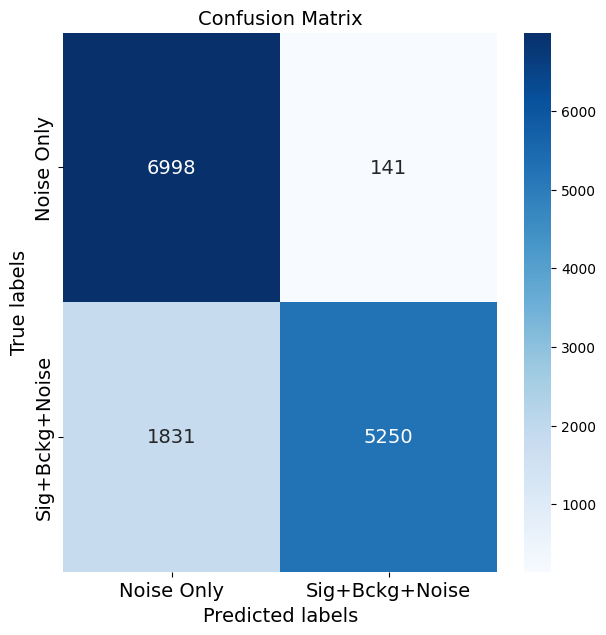

In [ ]:
import matplotlib.pyplot as plt
import os

target_dir = "/content/drive/MyDrive/project_files/Plots_no_time/"
os.makedirs(target_dir, exist_ok=True) # Crea la cartella se non esiste
plot_filename = f"{target_dir}confusion_matrix_{FREQ}kHz.png" # Nome file dinamico con FREQ

# --- Generazione e Salvataggio ---
print("Generazione Matrice di Confusione...")

# 1. Chiama la tua funzione esistente (che disegna il grafico)
confusion_matrix_image(cf_matrix)
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

print(f"✅ Immagine salvata correttamente in: {plot_filename}")

# 3. Ora stampa le performance
print_performances(cf_matrix)

In [ ]:
def values_TPR_TNR(cf_matrix):
    true_negative = cf_matrix[0][0]
    true_positive = cf_matrix[1][1]
    false_negative = cf_matrix[1][0]
    false_positive = cf_matrix[0][1]
    TNR = true_negative/(false_positive+true_negative)
    TPR = true_positive/(false_negative+true_positive)

    return TPR,TNR

In [ ]:

ReductionFactor = 5
tnr_limit = 1-1/ReductionFactor
opt_idx = 0
thresholds = np.linspace(0, 0.5, 10000)

for th in thresholds:
    cf_matrix, index_list = confusion_matrix_indexing(y_pred,y_test,index_test,threshold=th)
    tpr,tnr = values_TPR_TNR(cf_matrix)
    if(tnr>=tnr_limit):
        opt_idx = th
        print(f"Reduction Factor {ReductionFactor} Optimized threshold (TNR>=80%): {opt_idx:.5f}")
        print_performances(cf_matrix)
        break

Reduction Factor 5 Optimized threshold (TNR>=80%): 0.00900
Purity = 0.8127380170715692
Recall = 0.8740290919361672
Accuracy = 0.8369901547116737
TNR = 0.8002521361535229
TPR = 0.8740290919361672


In [ ]:
!pip install hls4ml

import hls4ml


hls4ml.model.optimizer.optimizer.layers = ['Activation']
hls4ml.model.optimizer.optimizer.rounding_mode = 'AP_RND'
hls4ml.model.optimizer.optimizer.saturation_mode = 'AP_SAT'

In [ ]:
print(np.asarray(model_input_train).shape)

(30, 142200, 42)


In [ ]:
################  DAM model definition #########################################################

qmodel = model

damI = []
damI_output_train = []
damI_output_test = []

sector_input_train = []
sector_input_test = []

dam_layer_name = 'fc6_'
#dam_layer_name = 'fc8_'

for sec in range(6):
    for subsec in range(5):

        input_index = subsec+sec*5
        damI_intermodel = Model(inputs=qmodel.input[input_index],
                        outputs=qmodel.get_layer(dam_layer_name+str(input_index)).output)
        damI.append(damI_intermodel)
        damI_intermodel.summary()

        damI_output_train.append(damI[input_index].predict(model_input_train[input_index], batch_size=1000))
        damI_output_test.append(damI[input_index].predict(model_input_test[input_index], batch_size=1000))

    sector_input_train.append(np.concatenate((damI_output_train[0+sec*5], damI_output_train[1+sec*5], damI_output_train[2+sec*5],
                                         damI_output_train[3+sec*5], damI_output_train[4+sec*5]), axis=-1))
    sector_input_test.append(np.concatenate((damI_output_test[0+sec*5], damI_output_test[1+sec*5], damI_output_test[2+sec*5],
                                         damI_output_test[3+sec*5], damI_output_test[4+sec*5]), axis=-1))

print(sector_input_train[0].shape)
print(sector_input_test[0].shape)

################  SECTOR model definition #########################################################


sector_mlp = []

first_layer_name = 'concatenate_'
last_layer_name = 'sector_fc6_'

sector_output_train = []
sector_output_test = []
WRONG=False
for sec in range(6):
    input_index = subsec+sec*5
    if(WRONG==True):
        sector_intermodel = Model(inputs=qmodel.get_layer('concatenate_'+str(sec+7)).output,
                        outputs=qmodel.get_layer(last_layer_name+str(sec)).output)
    else:
        sector_intermodel = Model(inputs=qmodel.get_layer(first_layer_name+str(sec)).output,
                        outputs=qmodel.get_layer(last_layer_name+str(sec)).output)
    sector_intermodel.summary()
    sector_mlp.append(sector_intermodel)
    sector_output_train.append(sector_mlp[sec].predict(sector_input_train[sec]))
    sector_output_test.append(sector_mlp[sec].predict(sector_input_test[sec]))

last_model_input_train = np.concatenate((sector_output_train[0], sector_output_train[1], sector_output_train[2],
                                         sector_output_train[3], sector_output_train[4], sector_output_train[5]), axis=-1)
last_model_input_test = np.concatenate((sector_output_test[0], sector_output_test[1], sector_output_test[2],
                                         sector_output_test[3], sector_output_test[4], sector_output_test[5]), axis=-1)

print(last_model_input_train.shape)
print(last_model_input_test.shape)

############ LAST Layer model ######################################################################

last_model = Model(inputs=qmodel.get_layer(first_layer_name+str(6)).output,
                        outputs=qmodel.get_layer('fc8_damII').output)
#last_model.summary()
last_predict_train = last_model.predict(last_model_input_train)
last_predict_test = last_model.predict(last_model_input_test)

Model: "functional_74"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input0 (InputLayer)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc4_0 (QDense)                  │ (None, 32)             │         5,634 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc5_0 (QDense)                  │ (None, 16)             │         2,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc6_0 (QDense)                  │ (None, 8)              │           596 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,442 (26.74 KB)

 Trainable params: 6,154 (24.04 KB)

 Non-trainable params: 2,288 (2.70 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_343CLONE           │ (None, 40)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sector_fc4_5 (QDense)           │ (None, 20)             │         3,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sector_fc5_5 (QDense)           │ (None, 16)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sector_fc6_5 (QDense)           │ (None, 4)              │           324 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,136 (16.25 KB)

 Trainable params: 3,708 (14.48 KB)

 Non-trainable params: 1,428 (1.77 KB)

4444/4444 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(142200, 24)
(14220, 24)
4444/4444 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
hls4ml.model.optimizer.optimizer.layers = ['Activation']
hls4ml.model.optimizer.optimizer.rounding_mode = 'AP_RND'
hls4ml.model.optimizer.optimizer.saturation_mode = 'AP_SAT'

# Note that without the above instruction the hls accuracy drop to 25% i.e. random choice among 4 classes

#   hls_config     = hls4ml.utils.config_from_keras_model(model, granularity='model')
#   hls_config     = hls4ml.utils.config_from_keras_model(model, granularity='name')

reuse_factor=1
hls_config_sector = []
for i in range(0,6):
    hls_config_sector.append(hls4ml.utils.config_from_keras_model(sector_mlp[i], granularity='name',default_precision='fixed<-1,0>',default_reuse_factor=reuse_factor))
    hls_config_sector[i]['Model']['Strategy'] = 'distributed_arithmetic'
    #hls_config_sector[i]['Model']['PipelineStyle']='pipeline'
    hls_config_sector[i]['Model']['PipelineInterval']='1'
    hls_config_sector[i]['Model']['BRAM']='True'
    hls_config_sector[i]['Model']['PipelineStyle']='dataflow'
#hls_config_sector['Model']["BramFactor"] = 1

hls_config_dam = []
for i in range(30):
    hls_config_dam.append(hls4ml.utils.config_from_keras_model(damI[i], granularity='name',default_precision='fixed<-1,0>'
                                                      ,default_reuse_factor=reuse_factor))
    hls_config_dam[i]['Model']['Strategy'] = 'distributed_arithmetic'
    hls_config_dam[i]['Model']['PipelineStyle']='pipeline'
    hls_config_dam[i]['Model']['PipelineInterval']='1'
    hls_config_dam[i]['Model']['BRAM']='True'
    hls_config_dam[i]['Model']['PipelineStyle']='dataflow'
#hls_config_sector['Model']["BramFactor"] = 1

hls_config_last_model    = hls4ml.utils.config_from_keras_model(last_model, granularity='name',default_precision='fixed<-1,0>'
                                                      ,default_reuse_factor=reuse_factor)
hls_config_last_model['Model']['Strategy'] = 'distributed_arithmetic'
hls_config_last_model['Model']['PipelineStyle']='dataflow'
#hls_config_last_model['Model']['PipelineStyle']='pipeline'
hls_config_last_model['Model']['PipelineInterval']='1'
hls_config_last_model['Model']['BRAM']='True'
#hls_config_sector['Model']["BramFactor"] = 1

In [ ]:
hls_model_dam = []

!pip install da4ml
import da4ml

for i in range(30):
    print("####### DAM MODEL {num} ###### \n".format(num=i))
    hls_model_dam.append(hls4ml.converters.convert_from_keras_model( damI[i],  hls_config   = hls_config_dam[i],
                                    output_dir   = "hw_dam_prova_{num}".format(num=i),
                                     part    = "xcvm1802-vsva2197-1MP-e-S",#"xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_DAM{num}".format(num=i),
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis'))
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
    hls_model_dam[i].compile()

####### DAM MODEL 0 ###### 

####### DAM MODEL 1 ###### 

####### DAM MODEL 2 ###### 



In [ ]:
#import os
#os.environ['PATH'] = '/opt/Xilinx/Vivado/2020.1/bin:' + os.environ['PATH']
#os.environ['PATH'] = '/opt/Xilinx/Vitis_HLS/2022.1/bin:' + os.environ['PATH']
#print(os.environ['PATH'])

In [ ]:
#hls_model_dam[0].build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True)

In [ ]:
#hls4ml.report.read_vivado_report("hw_dam_0")

In [ ]:
hls_model_sector = []

for i in range(6):
    print("####### SECTOR MODEL {num} ###### \n".format(num=i))
    hls_model_sector.append(hls4ml.converters.convert_from_keras_model( sector_mlp[i],  hls_config   = hls_config_sector[i],
                                    output_dir   = "hw_sector_prova_{num}".format(num=i),
                                     part    = "xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_Sec{num}".format(num=i),
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis'))
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
    hls_model_sector[i].compile()


In [ ]:
#hls_model_sector[0].build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True, fifo_opt=True)

In [ ]:
#hls4ml.report.read_vivado_report("hw_sector_0")

In [ ]:
hls_mlp_last_model = []


print("####### LAST MLP MODEL {num} ###### \n".format(num=i))
hls_mlp_last_model = hls4ml.converters.convert_from_keras_model( last_model,  hls_config   = hls_config_last_model,
                                    output_dir   = "hw_last_model_prova_{num}".format(num=i),
                                     part    = "xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_last",
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis')
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
hls_mlp_last_model.compile()


In [ ]:
#hls_mlp_last_model.build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True, fifo_opt=True)

In [ ]:
#hls4ml.report.read_vivado_report("hw_last_model_prova_0")

In [ ]:
hls_output_dam = []
hls4ml_output_sector = []
hls4ml_sector_input = []
for i in range(30):
    print("####### DAM MODEL {num} ###### \n".format(num=i))
    hls_output_dam.append(hls_model_dam[i].predict(np.ascontiguousarray(model_input_test[i]).astype(np.float32)))


print(np.asarray(hls_output_dam).shape)
for j in range(6):
    print("####### SECTOR MODEL {num} ###### \n".format(num=j))
    sector_input = np.concatenate((hls_output_dam[j*5],
                                   hls_output_dam[j*5+1],
                                   hls_output_dam[j*5+2],
                                   hls_output_dam[j*5+3],
                                   hls_output_dam[j*5+4],
                                  ), axis=1)
    hls4ml_sector_input.append(sector_input)
    print(np.asarray(hls4ml_sector_input).shape)
    hls4ml_output_sector.append(hls_model_sector[j].predict(hls4ml_sector_input[j]))

print(np.asarray(hls4ml_output_sector).shape)

aggregate_mlp_input = np.concatenate((hls4ml_output_sector[0],
                                   hls4ml_output_sector[1],
                                   hls4ml_output_sector[2],
                                   hls4ml_output_sector[3],
                                   hls4ml_output_sector[4],
                                   hls4ml_output_sector[5],
                                  ), axis=1)

print("####### AGGREGATE MLP MODEL ###### \n")
print(np.asarray(aggregate_mlp_input).shape)
#hls4ml_pred = hls_mlp_last_model.predict(np.ascontiguousarray(aggregate_mlp_input))

In [ ]:

# Test for mismatches
# HGQ2 and hls4ml should produce the same output, up to machine precision
# Notice that due to the quantization, internal mismatches may be amplified, but the vast majority of the output should match

keras_pred = model.predict(model_input_test)

print(f"{np.sum((keras_pred>0.5) != (hls4ml_pred>0.5))} / {np.prod(keras_pred.shape)} value mismatches")

In [ ]:
hls4ml_cf_matrix, hls4ml_index_list = confusion_matrix_indexing(hls4ml_pred,y_test,index_test,threshold=0.5)
print(hls4ml_cf_matrix)

In [ ]:
confusion_matrix_image(hls4ml_cf_matrix)
print_performances(hls4ml_cf_matrix)

In [ ]:
ReductionFactor = 5
tnr_limit = 1-1/ReductionFactor
opt_idx = 0
thresholds = np.linspace(0, 0.5, 10000)

for th in thresholds:
    hls4ml_cf_matrix, hls4ml_index_list = confusion_matrix_indexing(hls4ml_pred,y_test,index_test,threshold=th)
    tpr,tnr = values_TPR_TNR(hls4ml_cf_matrix)
    if(tnr>=tnr_limit):
        hls4ml_opt_idx = th
        print(f"Reduction Factor {ReductionFactor} Optimized threshold (TNR>=80%): {hls4ml_opt_idx:.5f}")
        print_performances(hls4ml_cf_matrix)
        break

In [ ]:
WRITE_OUTPUT_DATA = True

In [ ]:
if(WRITE_OUTPUT_DATA):
    import os

    # cartella output per i csv di noise
    OUTDIR = "intermediate_output_txt"
    os.makedirs(OUTDIR, exist_ok=True)

    for i in range(30):
        with open('intermediate_output_txt/damI_input_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, model_input_train[i])
        with open('intermediate_output_txt/damI_input_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, model_input_test[i])
        with open('intermediate_output_txt/damI_output_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, damI_output_train[i])
        with open('intermediate_output_txt/damI_output_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, damI_output_test[i])

        np.savetxt("intermediate_output_txt/damI_input_train_{num}.txt".format(num=i), model_input_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/damI_input_test_{num}.txt".format(num=i), model_input_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/damI_output_train_{num}.txt".format(num=i), damI_output_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/damI_output_test_{num}.txt".format(num=i), damI_output_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)

    for i in range(6):
        with open('intermediate_output_txt/sector_input_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_input_train[i])
        with open('intermediate_output_txt/sector_input_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_input_test[i])
        with open('intermediate_output_txt/sector_output_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_output_train[i])
        with open('intermediate_output_txt/sector_output_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_output_test[i])

        np.savetxt("intermediate_output_txt/sector_input_train_{num}.txt".format(num=i), sector_input_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_input_test_{num}.txt".format(num=i), sector_input_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_output_train_{num}.txt".format(num=i), sector_output_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_output_test_{num}.txt".format(num=i), sector_output_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)



    np.savetxt("intermediate_output_txt/last_model_input_train.txt",last_model_input_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_model_input_test.txt", last_model_input_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_predict_train.txt", last_predict_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_predict_test.txt", last_predict_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/y_train.txt", y_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/y_test.txt", y_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)

In [ ]:
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#

In [ ]:
FREQ=150

In [ ]:
import numpy as np

In [ ]:
signal_data1 = f"signal_data_{FREQ}kHz.npy"
noise_data1 = f"noise_data_{FREQ}kHz.npy"
s1=np.load(signal_data1)
n1=np.load(noise_data1)

In [ ]:
print(s1.shape)
print(n1.shape)

In [ ]:
print(s1.max())